Дерево решений делит пространство признаков на прямоугольные области с помощью последовательных сплитов вида [x 
j
​
 ≤t].

Алгоритм является жадным: оптимизирует качество каждого сплита локально "здесь и сейчас".

Качество сплита оценивается через Information Gain — насколько сильнее уменьшился хаос (Gini или Entropy) после разбиения.

Огромный плюс деревьев: Им не нужно масштабирование признаков (StandardScaler не нужен!), так как правила вида x 
j
​
 ≤t инвариантны к монотонным преобразованиям.

In [ ]:
# DecisionTreeClassifier

# max_depth - максимальная глубина дерева
# Маленькое значение (<=3) дает недообучение,
# слишком большое (>=15) — переобучение

# min_samples_split - минимальное количество объектов для разделения
# в узле осталось 8 объектов, сплит запрещается, и узел становится листом.

# min_samples_split - минимальное количество объектов которое должно 
# остаться после сплита
# Если один из дочерних листьев получает всего 1 объект, такой сплит отклоняется.

# max_leaf_nodes - ограничивает итоговое количество листьев в дереве

# ccp_alpha - сначала строит полное дерево, и отрезает самые бесполезные ветки

sepal length (cm): 0.0000
sepal width (cm): 0.0000
petal length (cm): 0.5841
petal width (cm): 0.4159


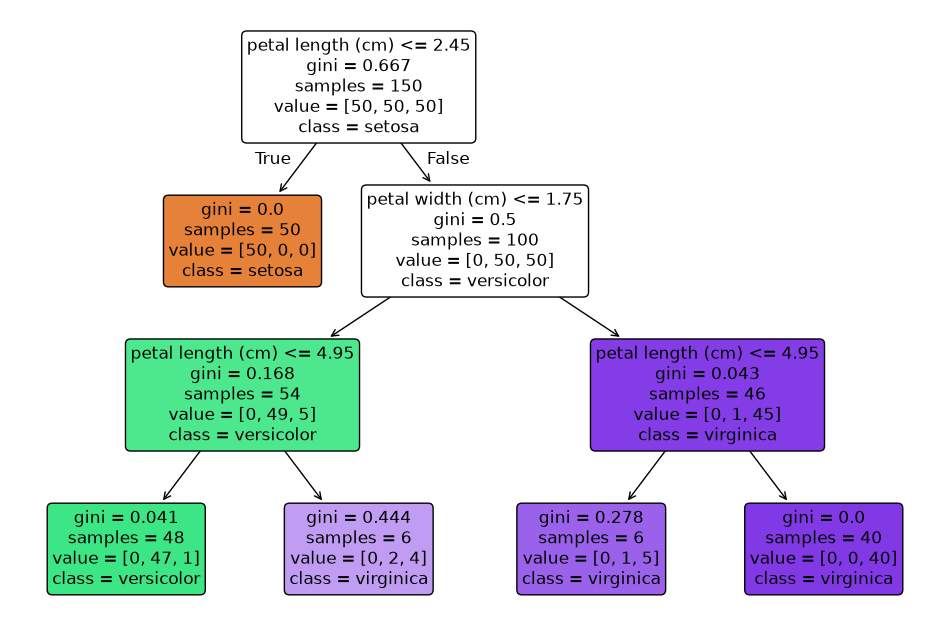

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Загрузка данных
iris = load_iris()
X, y = iris.data, iris.target

# 2. Обучение регуляризованного дерева
model = DecisionTreeClassifier(
    max_depth=3,               # Ограничение глубины
    min_samples_leaf=5,        # Не менее 5 объектов в листе
    criterion='gini',
    random_state=42
)
model.fit(X, y)

# 3. Важность признаков
for name, importance in zip(iris.feature_names, model.feature_importances_):
    print(f"{name}: {importance:.4f}")

# 4. Визуализация дерева правил
plt.figure(figsize=(12, 8))
plot_tree(
    model, 
    feature_names=iris.feature_names, 
    class_names=iris.target_names, 
    filled=True,               # Окрашивание узлов по преобладающему классу
    rounded=True
)
plt.show()